<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [45]:
housing = pd.read_csv('data/sacramento_real_estate_transactions.csv')

### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

__Note:__
- Assign the correct data type to each column.
- Look for missing values and determine how to handle them. Keep in mind that most machine learning models cannot process null values.
- Check the value ranges for numerical and categorical columns to identify any anomalies.
- Examine the distribution of values and investigate potential outliers.

In [46]:
housing.dtypes

street           str
city             str
zip            int64
state            str
beds           int64
baths          int64
sq__ft         int64
type             str
sale_date        str
price          int64
latitude     float64
longitude    float64
dtype: object

In [47]:
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [48]:
housing.describe()

,zip,beds,baths,sq__ft,price,latitude,longitude
count,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000
mean,95750.697462,2.911675,1.776650,1312.918782,233715.951269,38.445121,-121.193371
std,85.176072,1.307932,0.895371,856.123224,139088.818896,5.103637,5.100670
min,95603.000000,0.000000,0.000000,-984.000000,-210944.000000,-121.503471,-121.551704
25%,95660.000000,2.000000,1.000000,950.000000,145000.000000,38.482704,-121.446119
50%,95762.000000,3.000000,2.000000,1304.000000,213750.000000,38.625932,-121.375799
75%,95828.000000,4.000000,2.000000,1718.000000,300000.000000,38.695589,-121.294893
max,95864.000000,8.000000,5.000000,5822.000000,884790.000000,39.020808,38.668433


In [49]:
housing.value_counts(housing['state'])

state
CA    984
AC      1
Name: count, dtype: int64

In [50]:
#Check All cities in CA state? Yes
housing.value_counts(housing['city'])

city
SACRAMENTO         439
ELK GROVE          114
LINCOLN             72
ROSEVILLE           48
CITRUS HEIGHTS      35
ANTELOPE            33
RANCHO CORDOVA      28
EL DORADO HILLS     23
NORTH HIGHLANDS     21
GALT                21
CARMICHAEL          20
FOLSOM              17
ROCKLIN             17
RIO LINDA           13
ORANGEVALE          11
PLACERVILLE         10
FAIR OAKS            9
CAMERON PARK         9
WILTON               5
AUBURN               5
ELVERTA              4
GOLD RIVER           4
POLLOCK PINES        3
RANCHO MURIETA       3
GRANITE BAY          3
WEST SACRAMENTO      3
LOOMIS               2
EL DORADO            2
MATHER               1
GREENWOOD            1
MEADOW VISTA         1
PENRYN               1
FORESTHILL           1
DIAMOND SPRINGS      1
SHINGLE SPRINGS      1
COOL                 1
WALNUT GROVE         1
GARDEN VALLEY        1
SLOUGHHOUSE          1
Name: count, dtype: int64

In [51]:
housing.nlargest(10, 'sq__ft')

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
866,14151 INDIO DR,SLOUGHHOUSE,95683,CA,3,4,5822,Residential,Fri May 16 00:00:00 EDT 2008,2000,38.490447,-121.129337
864,9401 BARREL RACER CT,WILTON,95693,CA,4,3,4400,Residential,Fri May 16 00:00:00 EDT 2008,884790,38.415298,-121.194858
534,5201 BLOSSOM RANCH DR,ELK GROVE,95757,CA,4,4,4303,Residential,Mon May 19 00:00:00 EDT 2008,450000,38.399436,-121.444041
535,3027 PALMATE WAY,SACRAMENTO,95834,CA,5,3,4246,Residential,Mon May 19 00:00:00 EDT 2008,452000,38.628955,-121.529269
317,9760 LAZULITE CT,ELK GROVE,95624,CA,4,3,3992,Residential,Tue May 20 00:00:00 EDT 2008,460000,38.403609,-121.335541
328,7756 TIGERWOODS DR,SACRAMENTO,95829,CA,5,3,3984,Residential,Tue May 20 00:00:00 EDT 2008,572500,38.476430,-121.309243
319,5559 NORTHBOROUGH DR,SACRAMENTO,95835,CA,5,3,3881,Residential,Tue May 20 00:00:00 EDT 2008,471750,38.677225,-121.519687
855,9880 IZILDA CT,SACRAMENTO,95829,CA,5,4,3863,Residential,Fri May 16 00:00:00 EDT 2008,598695,38.453260,-121.325730
330,2981 WRINGER DR,ROSEVILLE,95661,CA,4,3,3838,Residential,Tue May 20 00:00:00 EDT 2008,613401,38.735373,-121.227072
552,12901 FURLONG DR,WILTON,95693,CA,5,3,3788,Residential,Mon May 19 00:00:00 EDT 2008,691659,38.413535,-121.188211


In [52]:
housing.nlargest(10, 'beds')

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
108,2912 NORCADE CIR,SACRAMENTO,95826,CA,8,4,3612,Multi-Family,Wed May 21 00:00:00 EDT 2008,282400,38.559505,-121.364839
157,315 JUMEL CT,EL DORADO HILLS,95762,CA,6,5,0,Residential,Wed May 21 00:00:00 EDT 2008,830000,38.669931,-121.059580
648,8198 STEVENSON AVE,SACRAMENTO,95828,CA,6,4,2475,Multi-Family,Fri May 16 00:00:00 EDT 2008,159900,38.465271,-121.404260
779,9452 RED SPRUCE WAY,ELK GROVE,95624,CA,6,3,2555,Residential,Fri May 16 00:00:00 EDT 2008,300000,38.404505,-121.346938
78,8373 BLACKMAN WAY,ELK GROVE,95624,CA,5,3,2136,Residential,Wed May 21 00:00:00 EDT 2008,223058,38.435436,-121.394536
91,8636 TEGEA WAY,ELK GROVE,95624,CA,5,3,2508,Residential,Wed May 21 00:00:00 EDT 2008,245918,38.443832,-121.382087
97,5529 LAGUNA PARK DR,ELK GROVE,95758,CA,5,3,2790,Residential,Wed May 21 00:00:00 EDT 2008,258000,38.425680,-121.438062
114,7731 MASTERS ST,ELK GROVE,95758,CA,5,3,2494,Residential,Wed May 21 00:00:00 EDT 2008,297000,38.442031,-121.410873
117,4727 SAVOIE WAY,SACRAMENTO,95835,CA,5,3,2800,Residential,Wed May 21 00:00:00 EDT 2008,304037,38.658182,-121.549521
119,9570 HARVEST ROSE WAY,SACRAMENTO,95827,CA,5,3,2367,Residential,Wed May 21 00:00:00 EDT 2008,315537,38.555993,-121.340352


In [53]:
housing['price_per_sqft'] = housing['price'] / housing['sq__ft']


In [54]:
housing.nsmallest(10, 'price_per_sqft')

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude,price_per_sqft
866,14151 INDIO DR,SLOUGHHOUSE,95683,CA,3,4,5822,Residential,Fri May 16 00:00:00 EDT 2008,2000,38.490447,-121.129337,0.343525
603,8208 WOODYARD WAY,CITRUS HEIGHTS,95621,CA,3,2,1166,Residential,Fri May 16 00:00:00 EDT 2008,30000,38.715322,-121.314787,25.728988
867,7401 TOULON LN,SACRAMENTO,95828,CA,4,2,1512,Residential,Thu May 15 00:00:00 EDT 2008,56950,38.488628,-121.387759,37.665344
335,5840 WALERGA RD,SACRAMENTO,95842,CA,2,1,840,Condo,Mon May 19 00:00:00 EDT 2008,40000,38.673678,-121.357471,47.619048
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028,58.450728
366,7342 GIGI PL,SACRAMENTO,95828,CA,4,4,1995,Multi-Family,Mon May 19 00:00:00 EDT 2008,120000,38.490704,-121.410176,60.150376
609,3348 40TH ST,SACRAMENTO,95817,CA,2,1,1080,Residential,Fri May 16 00:00:00 EDT 2008,65000,38.544162,-121.460652,60.185185
172,3847 LAS PASAS WAY,SACRAMENTO,95864,CA,3,1,1643,Residential,Tue May 20 00:00:00 EDT 2008,99000,38.588672,-121.373916,60.255630
607,2332 CAMBRIDGE ST,SACRAMENTO,95815,CA,2,1,1032,Residential,Fri May 16 00:00:00 EDT 2008,65000,38.608085,-121.449651,62.984496
337,261 REDONDO AVE,SACRAMENTO,95815,CA,3,1,970,Residential,Mon May 19 00:00:00 EDT 2008,61500,38.620685,-121.460539,63.402062


In [55]:
#Range prices
housing=housing[
    (housing["sq__ft"] >= 100) &
    (housing["sq__ft"] <= 15000)
    ]
#Range 
housing=housing[
    (housing["price"] >= 0) &
    (housing["price"] <= 2500000)
    ]
# Transform zip code to integer number
housing['zip'] = housing['zip'].astype('Int64')

# Range CA latitude and longitude

housing=housing[
    (housing["beds"] >= 1) &
    (housing["baths"] >= 1)
    ]

housing = housing[
    (housing['latitude'] >= 32.5) &
    (housing['latitude'] <= 42.0) &
    (housing['longitude'] >= -124.5) &
    (housing['longitude'] <= -114.1)
]
housing['sale_date'] = housing['sale_date'].str.replace(' EDT', '', regex=False)
housing['sale_date'] = pd.to_datetime(housing['sale_date'])

In [56]:
housing

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude,price_per_sqft
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879,70.839713
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028,58.450728
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839,86.532663
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146,81.346244
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768,102.760351
...,...,...,...,...,...,...,...,...,...,...,...,...,...
980,9169 GARLINGTON CT,SACRAMENTO,95829,CA,4,3,2280,Residential,2008-05-15,232425,38.457679,-121.359620,101.940789
981,6932 RUSKUT WAY,SACRAMENTO,95823,CA,3,2,1477,Residential,2008-05-15,234000,38.499893,-121.458890,158.429248
982,7933 DAFFODIL WAY,CITRUS HEIGHTS,95610,CA,3,2,1216,Residential,2008-05-15,235000,38.708824,-121.256803,193.256579
983,8304 RED FOX WAY,ELK GROVE,95758,CA,4,2,1685,Residential,2008-05-15,235301,38.417000,-121.397424,139.644510


In [57]:
#for more specific predict ignore most extreme values
low = housing['price'].quantile(0.05)
high = housing['price'].quantile(0.95)

housing = housing[housing['price'].between(low, high)]
housing.describe()

,zip,beds,baths,sq__ft,sale_date,price,latitude,longitude,price_per_sqft
count,731.0,731.000000,731.000000,731.000000,731,731.000000,731.000000,731.000000,731.000000
mean,95761.818057,3.262654,1.960328,1553.885089,2008-05-18 04:25:56.224350,219452.383037,38.575005,-121.382158,145.240285
min,95603.0,1.000000,1.000000,539.000000,2008-05-15 00:00:00,85000.000000,38.241514,-121.550527,60.150376
25%,95670.0,3.000000,2.000000,1161.000000,2008-05-16 00:00:00,155217.500000,38.472119,-121.452234,111.458980
50%,95820.0,3.000000,2.000000,1420.000000,2008-05-19 00:00:00,207973.000000,38.585291,-121.406824,137.559809
75%,95829.0,4.000000,2.000000,1800.000000,2008-05-20 00:00:00,274087.500000,38.675743,-121.328426,168.627436
max,95864.0,8.000000,4.000000,4303.000000,2008-05-21 00:00:00,452000.000000,39.008159,-120.597599,619.666048
std,85.377171,0.807135,0.610243,560.095846,NaN,84636.707809,0.127717,0.117572,47.456602


When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

In [58]:
housing.to_csv('./data/sacramento_cleaned_dataframe.csv', index=False)

### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

In [59]:
housing.corr(numeric_only=True)

,zip,beds,baths,sq__ft,price,latitude,longitude,price_per_sqft
zip,1.000000,-0.020357,-0.029718,-0.021767,-0.161464,-0.121605,-0.550067,-0.150159
beds,-0.020357,1.000000,0.616356,0.704778,0.378801,-0.127251,-0.002953,-0.287691
baths,-0.029718,0.616356,1.000000,0.700035,0.422132,-0.108394,0.032199,-0.238878
sq__ft,-0.021767,0.704778,0.700035,1.000000,0.670610,-0.125577,0.044281,-0.234869
price,-0.161464,0.378801,0.422132,0.670610,1.000000,0.016237,0.189010,0.508614
latitude,-0.121605,-0.127251,-0.108394,-0.125577,0.016237,1.000000,0.332360,0.140714
longitude,-0.550067,-0.002953,0.032199,0.044281,0.189010,0.332360,1.000000,0.167391
price_per_sqft,-0.150159,-0.287691,-0.238878,-0.234869,0.508614,0.140714,0.167391,1.000000


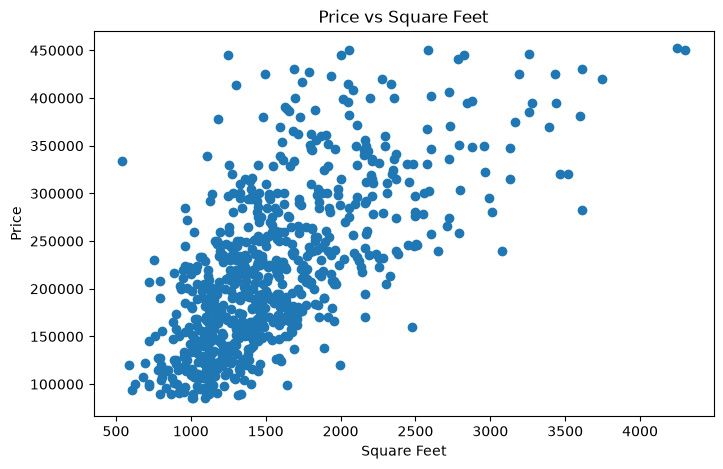

In [60]:
plt.figure(figsize=(8,5))
plt.scatter(housing['sq__ft'], housing['price'])
plt.xlabel('Square Feet')
plt.ylabel('Price')
plt.title('Price vs Square Feet')
plt.show()

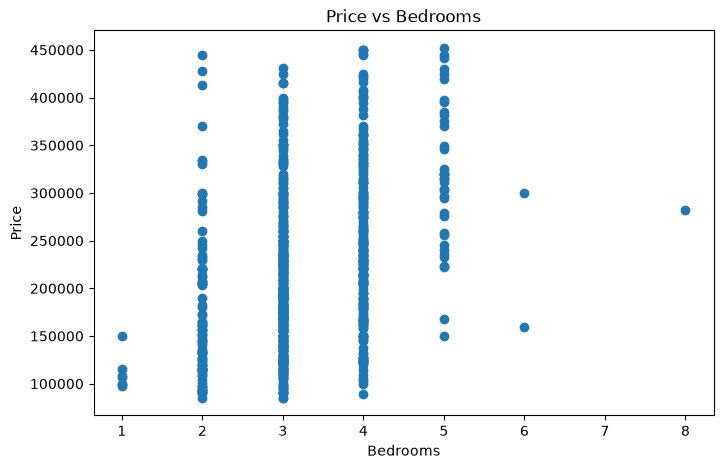

In [61]:
plt.figure(figsize=(8,5))
plt.scatter(housing['beds'], housing['price'])
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.title('Price vs Bedrooms')
plt.show()

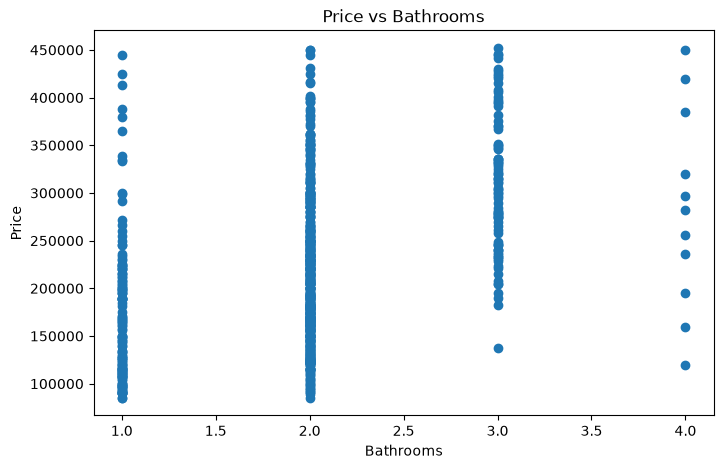

In [62]:
plt.figure(figsize=(8,5))
plt.scatter(housing['baths'], housing['price'])
plt.xlabel('Bathrooms')
plt.ylabel('Price')
plt.title('Price vs Bathrooms')
plt.show()

### 4. Which variable would be the best predictor of Y in an SLR model? Why?

In [63]:
## we can use sq__ft, because it has highest correlation with price as we see in prev step 
housing[['sq__ft']]


,sq__ft
5,1122
6,1104
7,1177
8,941
9,1146
...,...
980,2280
981,1477
982,1216
983,1685


### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [64]:
def slr(X,y):
    averageX = X.mean()
    averageY = y.mean()
    standardD_X = X.std()
    standardD_Y = y.std()
    r = X.corr(y)
    B1 = r * (standardD_Y / standardD_X)
    B0 = averageY-B1*averageX
    return B0, B1

In [65]:
X= housing['sq__ft']
y=housing['price']
slr(X,y)

(np.float64(61986.84992274013), np.float64(101.33666526378167))

### 6. Interpret the intercept and the slope.

In [66]:
B0,B1 = slr(X,y)
print("Intercept:", B0)
print("Slope:", B1)

Intercept: 61986.84992274013
Slope: 101.33666526378167


### 7. Give an example of how this model could be used for prediction and how it could be used for inference. 

**Be sure to make it clear which example is associated with prediction and which is associated with inference.**

#### Prediction:
The model can be used to predict the selling price of a house based on its square footage. For example, if a house has 2,000 square feet, we can substitute 2,000 into the regression equation to estimate its price.

#### Inference:
The model can also be used to understand the relationship between square footage and house price. The slope coefficient indicates how much the expected house price changes, on average, for each additional square foot. A positive slope suggests that larger houses generally sell for higher prices.

In [67]:
y_pred = B0 + B1*2000 
y_pred

np.float64(264660.1804503035)

### 8: [Bonus] Using the model you came up with in Problem 5, calculate and plot the residuals.

In [68]:
y_pred = B0 + B1 * X

residuals = y - y_pred

print("\nFirst residuals:")
print(residuals.head()) 


First residuals:
5   -85765.588349
6   -82967.528374
7   -90258.104938
8   -62439.651936
9   -79181.668315
dtype: float64


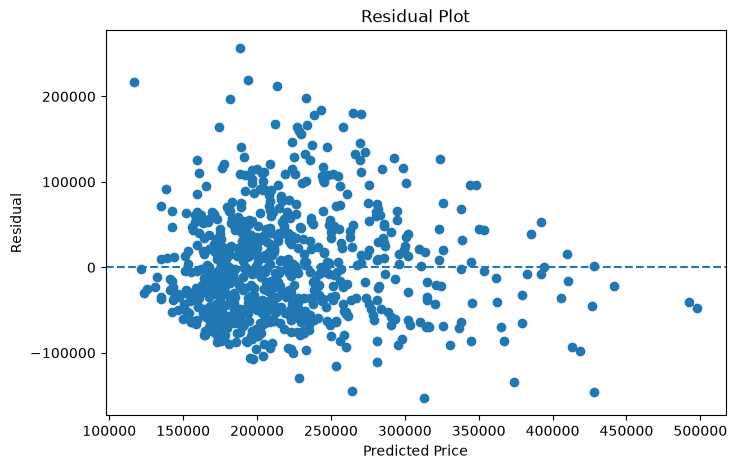

In [69]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Price')
plt.ylabel('Residual')
plt.title('Residual Plot')

plt.show()

In [70]:
SS_res = ((y - y_pred) ** 2).sum()
SS_tot = ((y - y.mean()) ** 2).sum()

# R-squared
R2 = 1 - (SS_res / SS_tot)

print("R =", R2**0.5)

R = 0.6706102674016634


In [71]:
#Bad model 

---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



###### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 9. Use the `pd.get_dummies` function to convert the `type` column into dummy-coded variables.

In [72]:
housing = pd.get_dummies(housing, columns=['type'], drop_first = True)

### 10. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [73]:
housing.head()

,street,city,zip,state,beds,baths,sq__ft,sale_date,price,latitude,longitude,price_per_sqft,type_Multi-Family,type_Residential
5,5828 PEPPERMILL CT,SACRAMENTO,95841,CA,3,1,1122,2008-05-21,89921,38.662595,-121.327813,80.143494,False,False
6,6048 OGDEN NASH WAY,SACRAMENTO,95842,CA,3,2,1104,2008-05-21,90895,38.681659,-121.351705,82.332428,False,True
7,2561 19TH AVE,SACRAMENTO,95820,CA,3,1,1177,2008-05-21,91002,38.535092,-121.481367,77.316907,False,True
8,11150 TRINITY RIVER DR Unit 114,RANCHO CORDOVA,95670,CA,2,2,941,2008-05-21,94905,38.621188,-121.270555,100.855473,False,False
9,7325 10TH ST,RIO LINDA,95673,CA,3,2,1146,2008-05-21,98937,38.700909,-121.442979,86.332461,False,True


### 11. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [74]:
housing.corr(numeric_only=True)


,zip,beds,baths,sq__ft,price,latitude,longitude,price_per_sqft,type_Multi-Family,type_Residential
zip,1.000000,-0.020357,-0.029718,-0.021767,-0.161464,-0.121605,-0.550067,-0.150159,0.029282,-0.018291
beds,-0.020357,1.000000,0.616356,0.704778,0.378801,-0.127251,-0.002953,-0.287691,0.200004,0.182192
baths,-0.029718,0.616356,1.000000,0.700035,0.422132,-0.108394,0.032199,-0.238878,0.246377,-0.007329
sq__ft,-0.021767,0.704778,0.700035,1.000000,0.670610,-0.125577,0.044281,-0.234869,0.118529,0.105387
price,-0.161464,0.378801,0.422132,0.670610,1.000000,0.016237,0.189010,0.508614,0.008086,0.142469
latitude,-0.121605,-0.127251,-0.108394,-0.125577,0.016237,1.000000,0.332360,0.140714,0.024195,-0.086312
longitude,-0.550067,-0.002953,0.032199,0.044281,0.189010,0.332360,1.000000,0.167391,0.033425,-0.008441
price_per_sqft,-0.150159,-0.287691,-0.238878,-0.234869,0.508614,0.140714,0.167391,1.000000,-0.070579,0.030835
type_Multi-Family,0.029282,0.200004,0.246377,0.118529,0.008086,0.024195,0.033425,-0.070579,1.000000,-0.525370
type_Residential,-0.018291,0.182192,-0.007329,0.105387,0.142469,-0.086312,-0.008441,0.030835,-0.525370,1.000000


In [75]:
X= housing[['sq__ft','beds', 'baths', 'type_Multi-Family', 'type_Residential']]
y=housing['price']
lr = LinearRegression()
lr.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 124.46,-21161.83, -4406.78, 6265.01, 34254.69]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['sq__ft','beds','baths','type_Multi-Family','type_Residential']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.147e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


### 12. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

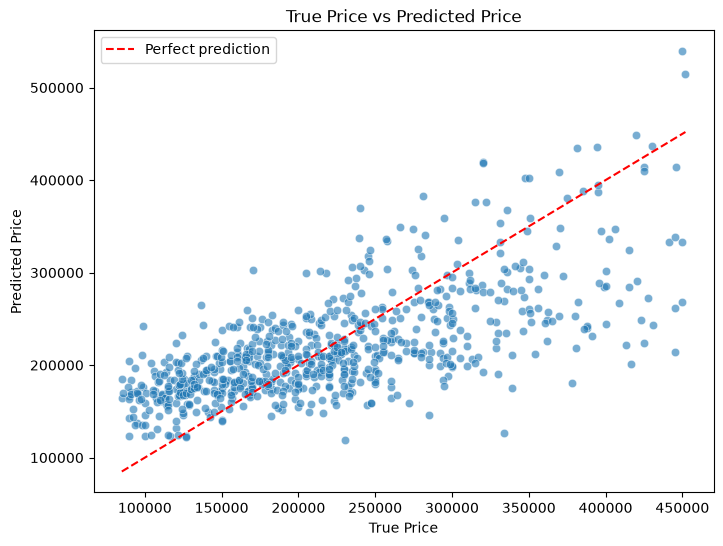

In [76]:
y_pred = lr.predict(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=y, y=y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color='red',
    linestyle='--',
    label='Perfect prediction'
)

plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("True Price vs Predicted Price")
plt.legend()
plt.show()

### 13. List the five assumptions for an MLR model. 

Indicate which ones are the same as the assumptions for an SLR model. 

1. **Linearity**
   The relationship between each independent variable (X) and the dependent variable (y) is linear — changes in X produce proportional changes in y.

2. **Independence of errors**
   The residuals (errors) are independent of each other. One observation's error shouldn't predict or influence another's (this matters especially in time-series data).

3. **Homoscedasticity**
   The residuals have constant variance across all levels of the predicted values. The spread of errors shouldn't grow or shrink as predicted values increase.

4. **Normality of residuals**
   The residuals are approximately normally distributed. This matters mainly for hypothesis testing / confidence intervals on coefficients, not for the predictions themselves.

5. **No multicollinearity**
   The independent variables (X) aren't highly correlated with each other. If two features carry basically the same information, it becomes hard for the model to tell which one is actually driving the outcome.



### 14. Pick at least two assumptions and explain whether or not you believe them to be met for your model, and explain why.

### Linearity — Questionable / Not clearly met

In the actual vs. predicted plot, points don't cluster tightly around the diagonal reference line — many points sit well above it, especially at lower predicted values, meaning the model is systematically underpredicting for a chunk of the data. This pattern (rather than random scatter around the line) suggests the true relationship between the features and price may not be fully linear, or that an important feature/interaction is missing from the model.

### No multicollinearity — Possibly met

The features (`sq_ft`, `beds`, `baths`, `type_Multi-Family`, `type_Residential`) don't have obviously overlapping information — this would ideally be confirmed with a correlation matrix or VIF (Variance Inflation Factor) scores, but there's no glaring redundancy just from the feature list itself.

### 15. Regression Metrics

Implement a function called `r2_adj()` that will calculate $R^2_{adj}$ for a model.

The adjusted R-squared is calculated as $R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$.

Unlike standard R-squared, which always increases when you add new variables, Adjusted R-squared will actually decrease if you add a useless variable to your model. This helps you find the simplest and most effective model.
- $R^2$: The standard R-squared value (coefficient of determination)
- $n$: The total number of observations (sample size)
- $k$: The number of independent variables (predictors) in your model

In [77]:
X.shape[0]
X.shape[1]

5

In [78]:
def r2_adj(model, X, y):
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    n = X.shape[0]   # number of observations
    k = X.shape[1]   # number of predictors
    r2_adjusted = 1 - ((1 - r2) * (n - 1)) / (n - k - 1)
    return r2_adjusted

In [79]:
r2_adj(lr, X, y)

0.4728365436192289

### 17. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

In [80]:
y_pred = lr.predict(X)

mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)
adj_r2 = r2_adj(lr, X, y)  # your function from Q15

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")
print(f"R:   {r2**0.5:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

MAE:  48313.00
MSE:  3745272744.97
RMSE: 61198.63
R²:   0.4764
R:   0.6903
Adjusted R²: 0.4728


### Typically the error is $61198.63 

### 18. Model Iteration

Adjust your model by adding or removing a variable. Then calculate the same regression metrics as you used in question 17. Has your model performance increased or decreased?

**Guidance:**
1. Look at the correlation between the dependent and independent variables. Which two predictors are the most correlated with each other?
2. Drop the one you think is less useful and refit the model with the remaining features.
3. Compare the new R2 and RMSE to your original model from Q11/Q17.


In [81]:
corr_with_price = housing[['sq__ft', 'beds', 'baths', 'price']].corr()['price']
print(corr_with_price)

X2 = housing[['sq__ft', 'beds', 'type_Multi-Family', 'type_Residential']]
y2 = housing['price']

lr2 = LinearRegression()
lr2.fit(X2, y2)
y_pred2 = lr2.predict(X2)

r2_2 = r2_score(y2, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y2, y_pred2))

print(f"New R²:   {r2_2:.4f}")
print(f"New RMSE: {rmse_2:.2f}")

print("\n--- Comparison ---")
print(f"Original R²:   {r2:.4f}   →   New R²:   {r2_2:.4f}")
print(f"Original RMSE: {rmse:.2f}   →   New RMSE: {rmse_2:.2f}")

sq__ft    0.670610
beds      0.378801
baths     0.422132
price     1.000000
Name: price, dtype: float64
New R²:   0.4760
New RMSE: 61225.75

--- Comparison ---
Original R²:   0.4764   →   New R²:   0.4760
Original RMSE: 61198.63   →   New RMSE: 61225.75


### 19. Add `city` as a feature


Use `OneHotEncoder` on the `city` column to add location as a feature. Since some cities only have 1-2 sales, group cities with fewer than 20 sales into `'Other'` first. Compare R2 and RMSE to the base model.

In [82]:
# Step 1: Count sales per city, then find which cities have fewer than 17 sales
city_counts = housing['city'].value_counts()
rare = city_counts[city_counts < 20].index

# Step 2: Group rare cities into 'Other'
housing['city_grouped'] = housing['city'].replace(rare, 'Other')

# Step 3: One-hot encode the grouped city column
encoder = OneHotEncoder(sparse_output=False, drop='first')
city_encoded = encoder.fit_transform(housing[['city_grouped']])

# Turn the encoded array into a DataFrame with proper column names
city_encoded_df = pd.DataFrame(
    city_encoded,
    columns= encoder.get_feature_names_out(['city_grouped']),
    index=housing.index
)


# Step 4: Combine with your existing features
X3 = pd.concat([housing[['sq__ft', 'beds', 'baths',
                          'type_Multi-Family', 'type_Residential']],
                 city_encoded_df], axis=1)
y3 = housing['price']

# Step 5: Fit the new model
lr3 = LinearRegression()
lr3.fit(X3, y3)
y_pred3 = lr3.predict(X3)

# Step 6: Metrics
r2_3 = r2_score(y3, y_pred3)
rmse_3 = np.sqrt(mean_squared_error(y3, y_pred3))

print(f"New R² (with city):   {r2_3:.4f}")
print(f"New RMSE (with city): {rmse_3:.2f}")

print(f"\nBase model R²:   {r2:.4f}")
print(f"Base model RMSE: {rmse:.2f}")

New R² (with city):   0.5331
New RMSE (with city): 57793.85

Base model R²:   0.4764
Base model RMSE: 61198.63


## Part 2: Sacramento Real Estate Deep Dive & Model Diagnostics

---

### 21. Beating the Baseline
A machine learning model is only useful if it performs better than a "naive guess". Create a baseline model:

Calculate the mean `price` of your training data to get the "Baseline" prediction, then, report how much money "on average" does your MLR model save us in pricing errors compared to just guessing using the average?

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X3, y, test_size=0.2, random_state=42)

# Step 1: Baseline prediction = mean price of training data
baseline_pred = y_train.mean()

# Step 2: "Predict" the baseline for every row (same value repeated)
baseline_predictions = np.full(len(y_train), baseline_pred)

# Step 3: Calculate baseline error (MAE is easiest to interpret in dollars)
baseline_mae = mean_absolute_error(y_train, baseline_predictions)
lr4 = LinearRegression()
lr4.fit(X_train, y_train)
# Step 4: Compare to your MLR model's MAE (on the same training data)
y_train_pred = lr4.predict(X_train)
model_mae = mean_absolute_error(y_train, y_train_pred)

# Step 5: How much money does the model save, on average?
savings = baseline_mae - model_mae

print(f"Baseline prediction (mean price): ${baseline_pred:,.2f}")
print(f"Baseline MAE:  ${baseline_mae:,.2f}")
print(f"Model MAE:     ${model_mae:,.2f}")
print(f"Average savings per prediction: ${savings:,.2f}")

Baseline prediction (mean price): $219,720.20
Baseline MAE:  $70,232.88
Model MAE:     $43,559.81
Average savings per prediction: $26,673.07


In [96]:
#  with scaling 

# Step 1: Baseline prediction = mean price of training data
baseline_pred = y_train.mean()

# Step 2: "Predict" the baseline for every row (same value repeated)
baseline_predictions = np.full(len(y_train), baseline_pred)

# Step 3: Calculate baseline error (MAE is easiest to interpret in dollars)
baseline_mae = mean_absolute_error(y_train, baseline_predictions)


scaler= StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 2. Transform the test features using the already-fitted scaler
X_test_scaled = scaler.transform(X_test)


# 3. Initialize, fit, and predict with the Linear Regression model
lr5 = LinearRegression()
lr5.fit(X_train_scaled, y_train)
y_pred_train = lr5.predict(X_train_scaled)
y_pred_test = lr5.predict(X_test_scaled)

model_mae = mean_absolute_error(y_train, y_train_pred)
# Step 5: How much money does the model save, on average?
savings = baseline_mae - model_mae

print(f"Baseline prediction (mean price): ${baseline_pred:,.2f}")
print(f"Baseline MAE:  ${baseline_mae:,.2f}")
print(f"Model MAE:     ${model_mae:,.2f}")
print(f"Average savings per prediction: ${savings:,.2f}")

Baseline prediction (mean price): $219,720.20
Baseline MAE:  $70,232.88
Model MAE:     $43,559.81
Average savings per prediction: $26,673.07


### 22. Which Feature Matters Most?
To explain our model accurately, we use **Feature Scaling** to force all features to be on a similar scale, allowing us to compare their "weight" equally.

Fit a new Linear Regression model on this **scaled** training data and find the new coefficients. Based on these scaled coefficients, which feature does the model actually rely on the most to determine a house's price?

In [97]:
from sklearn.pipeline import Pipeline

slr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

slr_pipe.fit(X_train, y_train)

coef = slr_pipe.named_steps['linear'].coef_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coef,
    'Absolute Coefficient': abs(coef)
})

feature_importance = feature_importance.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute Coefficient
0,sq__ft,64755.683415,64755.683415
9,city_grouped_Other,15279.859804,15279.859804
1,beds,-13080.086458,13080.086458
4,type_Residential,9704.612840,9704.612840
8,city_grouped_NORTH HIGHLANDS,-6847.620009,6847.620009
11,city_grouped_ROSEVILLE,6304.740616,6304.740616
12,city_grouped_SACRAMENTO,-6027.664258,6027.664258
3,type_Multi-Family,2632.216642,2632.216642
10,city_grouped_RANCHO CORDOVA,-2253.175339,2253.175339
6,city_grouped_ELK GROVE,944.784080,944.784080


#### NOTE: Rely on SQ_ft

### 23. Does the model generalize to the real world?
A model that perfectly memorizes the training data but fails completely on new unseen houses is useless. We call a model's ability to succeed on new data **Generalization**.

Using your scaled MLR model from Question 22:

* **Step 1:** Predict prices for the **training** set and calculate the training RMSE.

* **Step 2:** Predict prices for the **testing** set and calculate the testing RMSE.

Is the model performing significantly worse on the test data? What does this tell you about how the model generalizes?

In [98]:
# Predictions
y_train_pred = slr_pipe.predict(X_train)
y_test_pred = slr_pipe.predict(X_test)

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Training RMSE: {train_rmse:.2f}")
print(f"Testing RMSE : {test_rmse:.2f}")

Training RMSE: 57175.88
Testing RMSE : 60875.03


## Is the model performing significantly worse on test data?

**Not significantly.** The gap between training and testing RMSE is:

```
60,875.03 − 57,175.88 = $3,699.15
```

As a percentage increase:

```
3,699.15 / 57,175.88 × 100 ≈ 6.5%
```

A ~6.5% increase in error on unseen data is a **small, healthy gap** — not the kind of dramatic blow-up you'd see with a badly overfit model (like the sparse city-column model from Q25, where the gap could be huge).

## What this tells us about generalization

**The model generalizes reasonably well.** Here's the reasoning:

If the model had **memorized** the training data rather than learning real patterns, we'd expect training RMSE to be very low (near-perfect fit) while testing RMSE would be dramatically higher — a big warning sign of overfitting and high variance.


### 24. The Bias-Variance Tradeoff

In machine learning, there is a constant battle between Bias and Variance:
* **High Bias (Underfitting):** The model is very simple. It performs poorly on the training data as well as on the testing data.
* **High Variance (Overfitting):** The model is very complex. It memorizes the training data (high R-squared) but performs terribly on unseen testing data.
* **The Sweet Spot:** The model performs well on both the training set and the test set, with very little drop-off in performance.

Looking back at the Train and Test metrics you calculated for your Multiple Linear Regression model, is your model suffering from High Bias, High Variance, or is it in the sweet spot? Explain your reasoning.

- The model is in the sweet spot because the training RMSE (57,175.88) and testing RMSE (60,875.03) are very close. The small difference between these values indicates that the model generalizes well to unseen data.

### 25. Force High Variance to compare the outcomes
Let's see what the Bias-Variance Tradeoff looks like when we break the model on purpose! 

If we use `OneHotEncoder` on the `city` column **without** grouping the rare cities into "Other", we will a lot of new columns. Many of these columns will only have 1 or 2 houses in them. Explain the gap between the Train R-squared and Test R-squared.

#### What's happening:
Without grouping rare cities into 'Other', one-hot encoding creates a massive number of new columns — potentially one column per unique city, even for cities that only sold 1 or 2 houses total.

#### Why this causes a huge Train vs Test R² gap (classic overfitting):

Too many features, too little data per feature. If a city column has only 1 house in the entire dataset, and that house happens to land in the training set, the model can essentially "memorize" that specific house's price using that one column — instead of learning a real, generalizable pattern. It's not really learning "location affects price," it's learning "this exact house = this exact price."
High variance = the model is unstable. With so many sparse columns, the model has enormous flexibility to fit the training data almost perfectly (Train R² will look great, maybe 0.90+), because it has practically a custom column for tiny pockets of the data.


### 26. Interpreting & Explaining Results to Non-Technical Audiences
Data science is useless if the business doesn't understand your results. Avoid using technical jargon. How would you translate your model's performance for the executives?

 Our model predicts house prices with good accuracy and performs consistently on both the data it was trained on and new, unseen data. This means it is not simply memorizing past data but can make reliable predictions for future homes. While no prediction model is perfect, the results show that it provides dependable price estimates that can support better business decisions.